# Fit attraverso integrazione della posterior

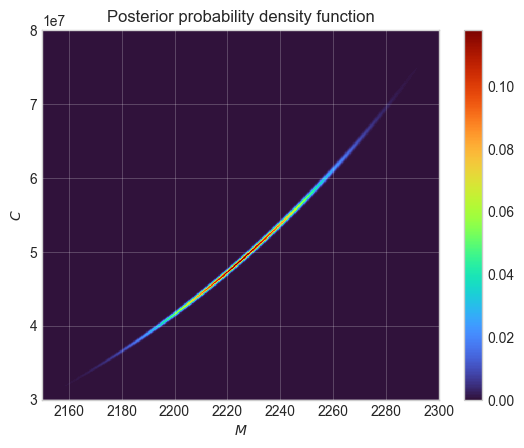

In [178]:
#FIT LINEARE CON MINIMI QUADRATI
import matplotlib.pyplot as plt

from matplotlib import cm

import numpy
from numpy import sqrt,floor

import numpy as np
import pandas as pd
import random
import math

# libreria locale
import my_lib_santanastasio as my
##NOTA IMPORTANTE: se cambi qualcosa in my_lib_santanastasio 
# devi fare Kernel --> Restart prima di rigirare il codice
# altrimenti i cambiamenti non saranno applicati.

from scipy import stats
import scipy.integrate as integrate
from scipy import optimize


def posterior(M, C, P, T, sigmaP):
    Yexp = C*np.exp(-M*18/R*(1/T))
    # Argomento = -M * 18 / R 
    # Derivata = Yexp * (Argomento / (T**2)) * -1
    # sigma_effective = np.sqrt(sigmaP**2 + (Derivata * uTemp)**2)
    # return np.prod(stats.norm.pdf(P, Yexp, sigma_effective))
    return np.prod(stats.norm.pdf(P, Yexp, sigmaP))

P0 = 101.57
uP0 = 0.5

offset = 0.15
uOffset = 0.003

Delta_pressioni = np.array([-89.79, -89.30, -89.33, -89.53])
Temp_multiple = np.array([49, 50, 50.6, 51.8])
uTemp = np.std(Temp_multiple, ddof=1)
uPress = np.std(Delta_pressioni, ddof=1)
Temp = np.array([np.mean(Temp_multiple), 56, 59.4, 64.8, 69.8, 74.4, 79.6, 84.6, 90.4]) + 273.15
Press = np.array([np.mean(Delta_pressioni), -85.88, -83.39, -78.26, -72.56, -67.59, -59.69, -50.01, -36.88])
Press = (np.array(Press) - offset + P0)
uPress = np.array(uPress)
uTemp = np.array(uTemp)
uPress = np.sqrt(uPress**2 + uOffset**2 + uP0**2)
uy_new = np.repeat(uPress, len(Press))
uy_new = np.array([0.02141572, 0.01296428, 0.01296428, 0.01296428, 0.01296428, 0.01296428,
 0.01296428, 0.01296428, 0.01296428]) * Press

R = 8.134

# Pi = 38560
Ti = 75+273.15


m_values = np.linspace(2150, 2300, 700)
c_values = np.linspace(3e7, 8e7, 700)

m_mesh, c_mesh = np.meshgrid(m_values, c_values)

posterior_values = np.zeros(len(m_values)*len(c_values))
idx = 0
for mval, cval in np.nditer([m_mesh,c_mesh]):
    posterior_values[idx]=posterior(M=mval, C=cval, T=Temp, sigmaP=uy_new, P=Press) 
    idx = idx + 1
posterior_mesh = posterior_values.reshape((len(c_values), len(m_values)))
fig, ax = plt.subplots()

im = ax.pcolormesh(
    m_mesh, c_mesh, posterior_mesh,
    shading='auto',
    cmap='turbo'
)

ax.set_axisbelow(False)
ax.grid(True, color='white', alpha=0.3, linewidth=0.5)

plt.colorbar(im, ax=ax)
ax.set_xlabel("$M$")
ax.set_ylabel("$C$")
ax.set_title("Posterior probability density function")
plt.savefig("Fit_posterior_aria_tot.png")
plt.show()

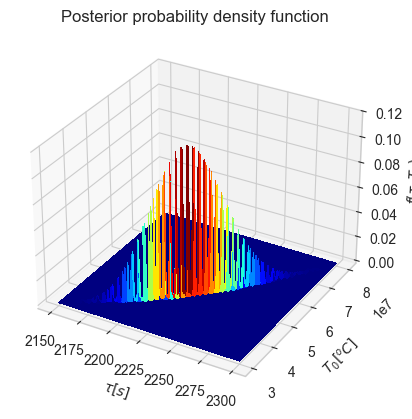

In [179]:
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(m_mesh, c_mesh, posterior_mesh, cmap=cm.jet,
                       linewidth=0, antialiased=False)

ax.set_xlabel('$\\tau [s]$')
ax.set_ylabel('$T_0 [^oC]$')
ax.set_zlabel('$f(\\tau,T_0)$')
plt.title("Posterior probability density function")
plt.savefig("grafico_3D.png")

In [180]:
range_m = (m_values[0], m_values[-1])
range_c = (c_values[0], c_values[-1])

# Integrale di normalizzazione della posterior
normalization, integral_error_norm = integrate.nquad(posterior, 
                                                    [range_m, range_c
                                                    ],
                                                    args=(Press ,Temp,uy_new)
                                                    )
print(normalization)

def posterior_norm(M,C,Y,X,SigmaY):    
    return posterior(M,C,Y,X,SigmaY) / normalization
 
def arg_E_m_k(M,C,k,Y,X,SigmaY):
    return np.power(M,k) * posterior_norm(M,C,Y,X,SigmaY)

def arg_Var_m(M,C,P, T, sigmaP, E_m):
    return (M - E_m)**2 * posterior_norm(M,C,P, T, sigmaP)

def arg_E_c_k(M,C,k,Y,X,SigmaY):
    return np.power(C,k) * posterior_norm(M,C,Y,X,SigmaY)

def arg_Var_c(M,C,P, T, sigmaP, E_c):
    return (C - E_c)**2 * posterior_norm(M,C,P, T, sigmaP)

def arg_E_mc(M,C,P, T, sigmaP):
    return C*M * posterior_norm(M,C,P, T, sigmaP)

3270977.336830268


In [181]:
E_c, error_int_E_c = integrate.nquad(arg_E_c_k, 
                                    [range_m, #m
                                    range_c  #c
                                    ],
                                    args=(1,Press, Temp, uy_new)#k=1
                                    )

Var_c, err_var = integrate.nquad(
    arg_Var_c,
    [range_m, range_c],
    args=(Press, Temp, uy_new, E_c)
)
Sigma_c = math.sqrt(Var_c)

In [182]:
E_m, error_int_E_m = integrate.nquad(arg_E_m_k, 
                                    [range_m, range_c],
                                    args=(1,Press, Temp, uy_new)
                                    )
Var_m, err_var = integrate.nquad(
    arg_Var_m,
    [range_m, range_c],
    args=(Press, Temp, uy_new, E_m)
)
Sigma_m = math.sqrt(Var_m)

In [183]:
E_mc, error_int_E_mc = integrate.nquad(arg_E_mc, 
                                       [range_m, #m
                                        range_c  #c
                                        ],
                                        args=(Press, Temp, uy_new)
                                        )
Cov_mc = E_mc - E_m*E_c
Rho_mc = Cov_mc / (Sigma_m*Sigma_c)

In [184]:
print(f"\n\nm_fit = {E_m:.20f} \\pm {Sigma_m:.20f} [y/x] [{Sigma_m/E_m*100:.2f}%]\n")
print(f"c_fit = {E_c:.20f} \\pm {Sigma_c:.20f} [y] [{Sigma_c/E_c*100:.2f}%]\n")
print(f"Cov[m,c] fit  = {Cov_mc}\n")
print(f"Rho[m,c] fit  = {Rho_mc}\n")

# t_pred = E_c*np.exp(-E_m*18/8.183(1/Temp - 1/Ti))
# residuals = t_pred - Press
# print(np.sum(residuals**2/uy_new**2)/(len(Press) - 2))



m_fit = 2227.42244578206600635895 \pm 20.03527771515243927070 [y/x] [0.90%]

c_fit = 49950652.75672093778848648071 \pm 6462704.90003765560686588287 [y] [12.94%]

Cov[m,c] fit  = 128879705.83428955

Rho[m,c] fit  = 0.995347760907763



# Distribuzione marginale di c

In [185]:
# def posterior_1(M, C, T, t, sigmaT, Tf):
#     Yexp = Tf - (Tf - C)*np.exp(-t/M)
#     return np.prod(stats.norm.pdf(T, Yexp, sigmaT))

# def posterior_1_norm(M,C,T,t,SigmaT, Tf):    
#     return posterior_1(M,C,T,t,SigmaT, Tf) / normalization

# posterior_norm_c = lambda C: integrate.nquad(posterior_1_norm, [range_m], args=(C,Temp,time,uy_new, Tf))[0]
# posterior_norm_c_vfunc = np.vectorize(posterior_norm_c)

# posterior_norm_c_values = posterior_norm_c_vfunc(c_values)

# plt.plot(c_values,posterior_norm_c_values,label='Posterior',linewidth=4)
# plt.xlabel("c")
# plt.ylabel("f(c)")
# plt.axvline(x = E_c, color = 'r', linestyle='-',label='E[c]')
# plt.axvline(x = E_c+Sigma_c, color = 'orange', linestyle='--', label='$E[c] \pm 1\sigma$')
# plt.axvline(x = E_c-Sigma_c, color = 'orange', linestyle='--')
# plt.plot(c_values, stats.norm.pdf(c_values,E_c,Sigma_c), linewidth=1, color='black',linestyle='--',label='Gaussian')
# plt.legend()
# plt.grid()

# Distribuzione marginale di m

<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:72: SyntaxWarning: invalid escape sequence '\s'
/var/folders/h7/5fmdn1ys2_g27vgk683vmkc80000gn/T/ipykernel_73144/1158127675.py:35: SyntaxWarning: invalid escape sequence '\p'
  linewidth=2, alpha=0.8, label=f'$E[m] \pm \sigma_m$', zorder=6)
/var/folders/h7/5fmdn1ys2_g27vgk683vmkc80000gn/T/ipykernel_73144/1158127675.py:41: SyntaxWarning: invalid escape sequence '\p'
  alpha=0.15, color='#F18F01', label='$\pm 1\sigma$ region')
/var/folders/h7/5fmdn1ys2_g27vgk683vmkc80000gn/T/ipykernel_73144/1158127675.py:72: SyntaxWarning: invalid escape sequence '\s'
  stats_text = f'$E[m] = {E_m:.3f}$\n$\sigma_m = {Sigma_m:.3f}$\n$[{E_m-Sigma_m:.3f}, {E_m+Sigma_m:.3f}]$'


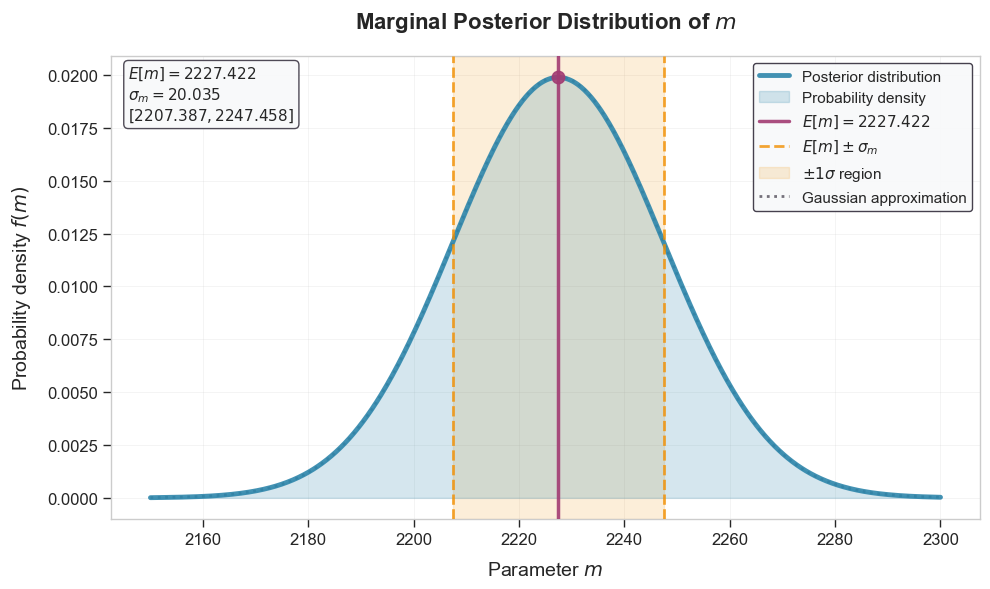

In [186]:
def posterior_2(C, M, P, T, sigma):
    Yexp = C*np.exp(-M*18/R*(1/T))
    return np.prod(stats.norm.pdf(P, Yexp, sigma))

def posterior_2_norm(C, M, P, T, sigma):    
    return posterior_2(C, M, P, T, sigma) / normalization

posterior_norm_m = lambda M: integrate.nquad(posterior_2_norm, [range_c], args=(M, Press, Temp, uy_new))[0]
posterior_norm_m_vfunc = np.vectorize(posterior_norm_m)

posterior_norm_m_values = posterior_norm_m_vfunc(m_values)

# Crea figura con dimensione ottimale
fig, ax = plt.subplots(figsize=(10, 6), dpi=100, facecolor='white')

# Plot principale con colore moderno
ax.plot(m_values, posterior_norm_m_values, 
        label='Posterior distribution', 
        linewidth=3.5, 
        color='#2E86AB',  # Blu moderno
        alpha=0.9,
        zorder=5)

# Aggiungi area shaded sotto la curva per enfasi
ax.fill_between(m_values, 0, posterior_norm_m_values, 
                alpha=0.2, color='#2E86AB', 
                label='Probability density',
                zorder=4)

# Linee verticali con stili distinti
ax.axvline(x=E_m, color='#A23B72', linestyle='-', 
          linewidth=2.5, alpha=0.9, label=f'$E[m] = {E_m:.3f}$', zorder=6)

ax.axvline(x=E_m + Sigma_m, color='#F18F01', linestyle='--', 
          linewidth=2, alpha=0.8, label=f'$E[m] \pm \sigma_m$', zorder=6)
ax.axvline(x=E_m - Sigma_m, color='#F18F01', linestyle='--', 
          linewidth=2, alpha=0.8, zorder=6)

# Aggiungi area shaded per la regione ±1σ
ax.axvspan(E_m - Sigma_m, E_m + Sigma_m, 
          alpha=0.15, color='#F18F01', label='$\pm 1\sigma$ region')

# Gaussiana di riferimento con stile più sottile
ax.plot(m_values, stats.norm.pdf(m_values, E_m, Sigma_m), 
        linewidth=2, 
        color='#3C3744', 
        linestyle=':', 
        label='Gaussian approximation',
        alpha=0.7,
        zorder=3)

# Labels con font size migliorato
ax.set_xlabel('Parameter $m$', fontsize=14, fontweight='medium', labelpad=10)
ax.set_ylabel('Probability density $f(m)$', fontsize=14, fontweight='medium', labelpad=10)

# Titolo descrittivo
ax.set_title('Marginal Posterior Distribution of $m$', 
             fontsize=16, fontweight='bold', pad=20)

# Legend con posizione ottimale e trasparenza
legend = ax.legend(loc='upper right', frameon=True, framealpha=0.95, 
                   edgecolor='#3C3744', fancybox=True, fontsize=11)
legend.get_frame().set_facecolor('#F8F9FA')

# Grid sottile e leggero
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Migliora ticks
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1)

# Aggiungi informazioni statistiche in testo
stats_text = f'$E[m] = {E_m:.3f}$\n$\sigma_m = {Sigma_m:.3f}$\n$[{E_m-Sigma_m:.3f}, {E_m+Sigma_m:.3f}]$'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#F8F9FA', 
                 alpha=0.9, edgecolor='#3C3744', linewidth=1))

# Aggiungi peak value marker
peak_idx = np.argmax(posterior_norm_m_values)
peak_m = m_values[peak_idx]
peak_val = posterior_norm_m_values[peak_idx]
ax.plot(peak_m, peak_val, 'o', markersize=9, 
        color='#A23B72', alpha=0.9, zorder=7,
        label=f'Mode = {peak_m:.3f}')

# Opzionale: aggiungi annotazione per il peak
# ax.annotate(f'Mode: {peak_m:.3f}', 
#            xy=(peak_m, peak_val), 
#            xytext=(peak_m+0.5, peak_val*0.8),
#            arrowprops=dict(arrowstyle='->', color='#A23B72', alpha=0.7),
#            fontsize=10, color='#3C3744')

# Layout tight
plt.tight_layout()

# Mostra plot
plt.show()

